## Social Networks with Monks: Numpyro version.  Model reciprocity in Monk "likes" with receiving effects.
By Prabhakar Srivatava

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import jax.numpy as jnp
from jax.random import PRNGKey, split
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import arviz as az
from jax.scipy.special import expit

In [2]:
# Random seed and plotting style
random_seed = sum(map(ord, "Homework B5 Monks Social Networks Numpyro Version"))

plt.style.use("statistical-rethinking-2023.mplstyle")

numpyro.set_host_device_count(4)
numpyro.enable_x64()

Import the Data

In [3]:
filepath_str:str = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Monks.csv"

monks_df = pd.read_csv(filepath_str, sep=";")

In [4]:
# Create the ids
monks_df["dyad_id_"] = monks_df["dyad_id"]
monks_df["dyad_id"] = monks_df["dyad_id_"].sub(1) # Convert id 1 indexing to 0 indexing
monks_df["A_id"] = monks_df["A"].sub(1) 
monks_df["B_id"] = monks_df["B"].sub(2) # Counting begins here at 2

monks_df.head()

,dyad_id,A,B,like_AB,like_BA,dislike_AB,dislike_BA,A_name,B_name,dyad_id_,A_id,B_id
0,0,1,2,0,3,0,0,ROMUL,BONAVEN,1,0,0
1,1,1,3,3,3,0,0,ROMUL,AMBROSE,2,0,1
2,2,1,4,0,0,0,0,ROMUL,BERTH,3,0,2
3,3,1,5,0,0,0,0,ROMUL,PETER,4,0,3
4,4,1,6,0,0,0,0,ROMUL,LOUIS,5,0,4


In [5]:
monks_df.tail()

,dyad_id,A,B,like_AB,like_BA,dislike_AB,dislike_BA,A_name,B_name,dyad_id_,A_id,B_id
148,148,15,17,0,0,0,0,AMAND,ELIAS,149,14,15
149,149,15,18,0,0,0,0,AMAND,SIMP,150,14,16
150,150,16,17,0,0,0,0,BASIL,ELIAS,151,15,15
151,151,16,18,0,0,0,0,BASIL,SIMP,152,15,16
152,152,17,18,3,3,0,0,ELIAS,SIMP,153,16,16


Model for the Monks Social Network: Giving is fixed since each monk gives 3 likes <br>
<center> $G_{AB} = \text{invlogit}(p_{AB})$ </center>
<center> $p_{AB} = \alpha + T_{AB} + R_B$ </center>
<center> $G_{BA} = \text{invlogit}(p_{BA})$ </center>
<center> $p_{BA} = \alpha + T_{BA} + R_A$ </center>
<center> $\begin{pmatrix} T_{AB} \\ T_{BA} \end{pmatrix} \sim 
    \text{MvNormal}(\begin{bmatrix} 0 \\ 0\end{bmatrix},
    \begin{bmatrix}\sigma^2 & \rho \sigma^2  \\ \rho \sigma^2 & \sigma^2 \end{bmatrix} )$ </center>
<center> $\alpha \sim \text{Normal}(0,1)$</center>
<center> $R_{A(B)} \sim \text{Normal}(0,1)$</center>

In [6]:
A_names = monks_df["A_name"].unique()
B_names = monks_df["B_name"].unique()

Numpyro Model

In [7]:
def hm_b5(D:jnp.array=jnp.array(monks_df["dyad_id"].values), 
          A:jnp.array=jnp.array(monks_df["A_id"].values),
          B:jnp.array=jnp.array(monks_df["B_id"].values),
          like_AB_obs:jnp.array=jnp.array(monks_df["like_AB"].values),
          like_BA_obs:jnp.array=jnp.array(monks_df["like_BA"].values),
          NCORRELATED:int = 2
         ) -> None:
    '''
    Social Network for Monks

    Args:
        D: dyad_id
        A: A_id
        B: B_id
        like_AB_obs: Number of likes A to B
        like_BA_obs: Number of likes B to A
        NCORRELATED: Number of correlated features
    '''

    # Priors
    α = numpyro.sample("α", dist.Normal(loc=0., scale=1.)) # Intercept

    # Generalized Receiving Effects:
    σ_R_A = numpyro.sample("σ_R_A", dist.Exponential(1.)) # A receives
    σ_R_B = numpyro.sample("σ_R_B", dist.Exponential(1.)) # B receives

    nA = len(np.unique(A)) # Length of A: to be used in plate below
    nB = len(np.unique(B)) # Length of B: to be used in plate below
    with numpyro.plate("nA", nA) as plate_A:
        Z_A = numpyro.sample("Z_A", dist.Normal(loc=0., scale=1.))
    with numpyro.plate("nB", nB) as plate_B:
        Z_B = numpyro.sample("Z_B", dist.Normal(loc=0., scale=1.))

    R_A = numpyro.deterministic("R_A", σ_R_A * Z_A)
    R_B = numpyro.deterministic("R_B", σ_R_B * Z_B)

    # Correlated Ties within dyads
    σ = numpyro.sample("σ", dist.Exponential(1.))
    # Correlation matrix
    L = numpyro.sample("L", dist.LKJCholesky(NCORRELATED, concentration=2.)) # Has dims of 2
    chol = jnp.array([σ, σ])[:, None] * L
    nD = len(np.unique(D)) # Number of dyads
    Z = numpyro.sample("Z", dist.Normal(loc=0., scale=1.).expand([nD, NCORRELATED]))
    T = numpyro.deterministic("T", (chol @ Z.T).T)
    ρ = numpyro.deterministic("ρ", L @ L.T)

    # Likelihoods:
    # Linear Regression Components
    p_AB = expit(α + T[D, 0] + R_B[B]) # A gives, B receives
    p_BA = expit(α + T[D, 1] + R_A[A]) # B gives, A receives

    like_AB = numpyro.sample("like_AB", dist.Binomial(3, probs=p_AB), obs=like_AB_obs)
    like_BA = numpyro.sample("like_BA", dist.Binomial(3, probs=p_BA), obs=like_BA_obs)    

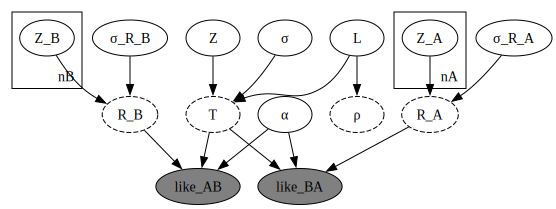

In [8]:
numpyro.render_model(hm_b5)

In [9]:
rng_key = PRNGKey(random_seed)
rng_key, rng_subkey = split(rng_key)
mcmc = MCMC(NUTS(hm_b5), num_samples=2_000, num_chains=4, num_warmup=1_000)
mcmc.run(rng_subkey)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

In [10]:
# mcmc.print_summary()

In [11]:
idata = az.from_numpyro(
    mcmc,
    coords={"dyads": np.arange(len(monks_df)),
            "A": A_names,
            "B": B_names,
            "monks": ["A", "B"]
           },
    dims={"R_A": ["A"],
          "R_B": ["B"],
          "T": ["dyads", "monks"]
         }
)

In [12]:
az.summary(idata, var_names = ["α", "σ", "ρ"], round_to=2)

/Users/prabh/miniconda3/envs/bap3/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/prabh/miniconda3/envs/bap3/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,-4.19,0.45,-5.05,-3.39,0.01,0.00,4565.57,5471.01,1.0
σ,3.33,0.44,2.53,4.14,0.01,0.01,3266.86,4382.15,1.0
"ρ[0, 0]",1.00,0.00,1.00,1.00,0.00,NaN,8000.00,8000.00,NaN
"ρ[0, 1]",0.68,0.11,0.48,0.89,0.00,0.00,1814.92,2704.94,1.0
"ρ[1, 0]",0.68,0.11,0.48,0.89,0.00,0.00,1814.92,2704.94,1.0
"ρ[1, 1]",1.00,0.00,1.00,1.00,0.00,0.00,7939.95,7964.72,1.0


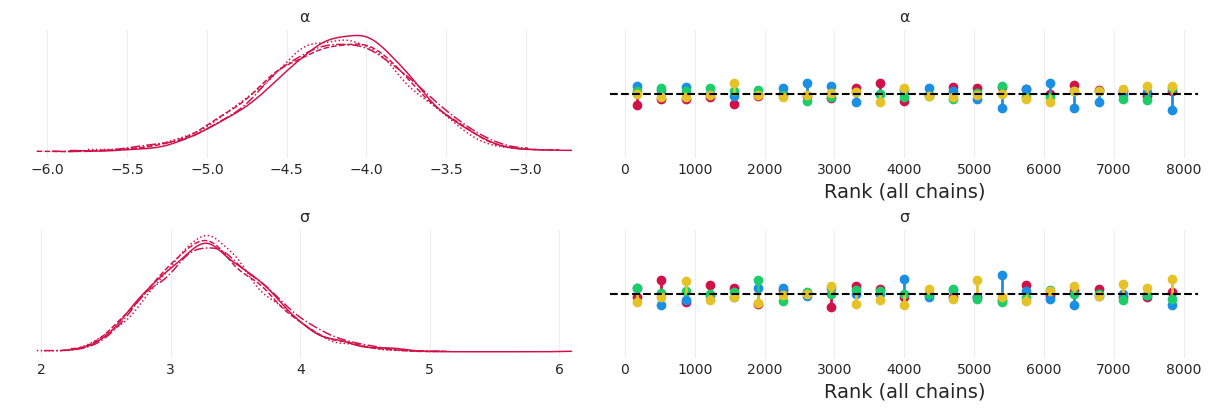

In [13]:
az.plot_trace(idata, var_names=["α", "σ"], kind="rank_vlines")
plt.show()

Plot the correlation of ties among dyads

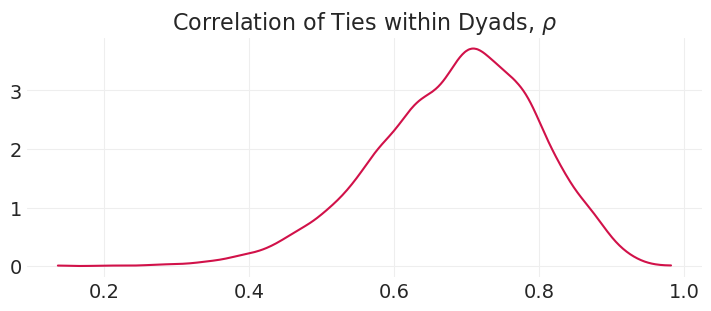

In [14]:
fig, ax = plt.subplots(figsize=(7., 3.))
az.plot_dist(
    idata.posterior["ρ"].sel(ρ_dim_0=0, ρ_dim_1=1),
    ax=ax
)
ax.set_title(r"Correlation of Ties within Dyads, $\rho$")
plt.show()

Plot of Reciprocity of Ties

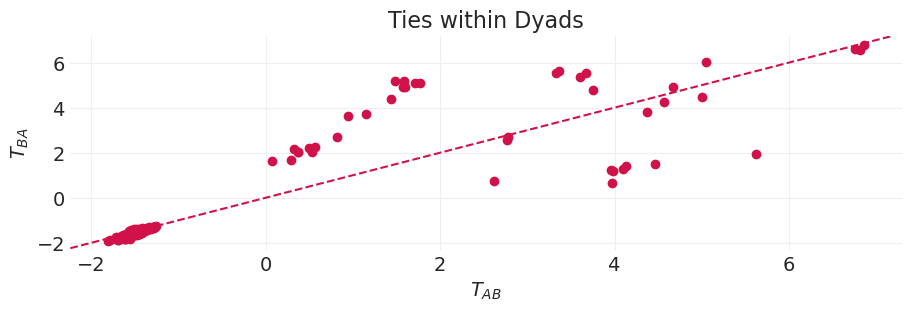

In [15]:
fig, ax = plt.subplots(figsize=(9., 3.))
T_AB = idata.posterior["T"].sel(monks="A").mean(dim=("chain", "draw"))
T_BA = idata.posterior["T"].sel(monks="B").mean(dim=("chain", "draw"))
ax.scatter(T_AB, T_BA)
ax.axline((0,0), slope=1, linestyle="--")
ax.set_xlabel(r"$T_{AB}$"); ax.set_ylabel(r"$T_{BA}$"); ax.set_title("Ties within Dyads")
plt.show()

Plot of receiving effects

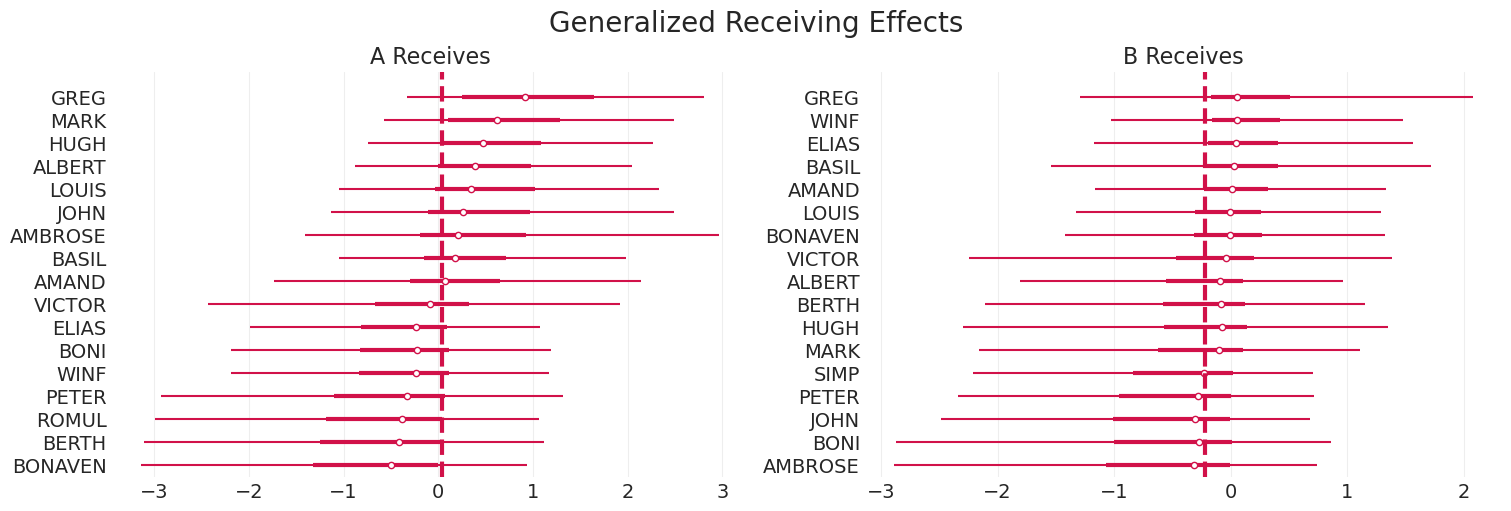

In [16]:
_, axes = plt.subplots(figsize=(15., 5.), nrows=1, ncols=2)
mean_RA = idata.posterior["R_A"].mean()
mean_RB = idata.posterior["R_B"].mean()
ids_RA = np.argsort(idata.posterior["R_A"].mean(dim=("chain", "draw")))[::-1]
ids_RB = np.argsort(idata.posterior["R_B"].mean(dim=("chain", "draw")))[::-1]

az.plot_forest(
    idata.posterior["R_A"].values[:, :, ids_RA],
    combined=True,
    ax=axes[0]
)
axes[0].set_yticklabels(A_names[ids_RA])
axes[0].axvline(mean_RA, ls="--", lw=3.)
axes[0].set_title("A Receives")

az.plot_forest(
    idata.posterior["R_B"].values[:, :, ids_RB],
    combined=True,
    ax=axes[1]
)
axes[1].set_yticklabels(B_names[ids_RB])
axes[1].axvline(mean_RB, ls="--", lw=3.)
axes[1].set_title("B Receives")

plt.suptitle("Generalized Receiving Effects", fontsize=20)
plt.show()

In [17]:
ids_RA

<xarray.DataArray 'R_A' (A: 17)> Size: 136B
array([ 1,  3,  0,  4,  7, 11, 16,  6, 14, 15,  2,  8,  5, 13, 10, 12,  9])
Coordinates:
  * A        (A) object 136B 'ELIAS' 'BASIL' 'AMAND' ... 'BONAVEN' 'ROMUL'

In [18]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data